# Data Ingestion and Preprocessing

Load the application and credit record datasets, merge them, and label applicants as good or bad.

In [53]:
import numpy as np
import pandas as pd
import os

application = pd.read_csv("application_record.csv")
credit = pd.read_csv("credit_record.csv")

print("Application records shape:", application.shape)
print("Credit records shape:", credit.shape)
print("\nApplication columns:", list(application.columns))
print("Credit columns:", list(credit.columns))

Application records shape: (438557, 18)
Credit records shape: (1048575, 3)

Application columns: ['ID', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS']
Credit columns: ['ID', 'MONTHS_BALANCE', 'STATUS']


In [54]:
print("Application sample:")
display(application.head())

print("\nCredit record sample:")
display(credit.head())

Application sample:


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0



Credit record sample:


,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


## Merge Application and Credit Records

Join on `ID`. Applicants without a matching credit record are dropped since we
cannot determine their payment behaviour without credit history.

In [55]:
# Inner join keeps only applicants that have credit records
# Unmatched applicants (no credit history) are dropped
df = application.merge(credit, on="ID", how="inner")

n_app_before = application["ID"].nunique()
n_app_after = df["ID"].nunique()
n_dropped = n_app_before - n_app_after

print(f"Applicants before merge: {n_app_before}")
print(f"Applicants after merge:  {n_app_after}")
print(f"Dropped (no credit record): {n_dropped}")
print(f"\nMerged dataset shape: {df.shape}")
display(df.head())

Applicants before merge: 438510
Applicants after merge:  36457
Dropped (no credit record): 402053

Merged dataset shape: (777715, 20)


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,MONTHS_BALANCE,STATUS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,0,C
1,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-1,C
2,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-2,C
3,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-3,C
4,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-4,C


## Label Applicants as Good or Bad

**STATUS codes in credit_record.csv:**
- `C` — paid off that month
- `X` — no loan for that month
- `0` — 1-29 days past due
- `1` — 30-59 days past due
- `2` — 60-89 days past due
- `3` — 90-119 days past due
- `4` — 120-149 days past due
- `5` — 150+ days past due / bad debt

An applicant is labelled **bad** (1) if they were ever **90+ days past due**
(STATUS ∈ {3, 4, 5}), and **good** (0) otherwise.

In [56]:
def label_applicants(merged_df: pd.DataFrame) -> pd.DataFrame:
    """Label each applicant as good (0) or bad (1).

    An applicant is 'bad' if they were ever 90+ days past due on any payment
    (STATUS in {'3', '4', '5'}). Everyone else is 'good'.

    Returns a DataFrame with one row per applicant and a 'target' column.
    """
    bad_statuses = {"3", "4", "5"}

    # Flag each row where the applicant was 90+ days overdue
    merged_df = merged_df.copy()
    merged_df["is_bad"] = merged_df["STATUS"].astype(str).isin(bad_statuses).astype(int)

    # Aggregate per applicant: bad if they were EVER 90+ days overdue
    labels = merged_df.groupby("ID")["is_bad"].max().reset_index()
    labels.rename(columns={"is_bad": "target"}, inplace=True)

    # Merge labels back onto the applicant-level data (drop credit rows)
    applicant_df = merged_df.drop(columns=["MONTHS_BALANCE", "STATUS", "is_bad"])
    applicant_df = applicant_df.drop_duplicates(subset="ID")
    applicant_df = applicant_df.merge(labels, on="ID", how="inner")

    return applicant_df

In [57]:
labelled_df = label_applicants(df)

print(f"Labelled dataset shape: {labelled_df.shape}")
print(f"\nTarget distribution:")
print(labelled_df["target"].value_counts().rename({0: "Good", 1: "Bad"}))
print(f"\nBad rate: {labelled_df['target'].mean():.2%}")
display(labelled_df.head())

Labelled dataset shape: (36457, 19)

Target distribution:
target
Good    36155
Bad       302
Name: count, dtype: int64

Bad rate: 0.83%


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,target
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0,0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,0


# Exploratory Data Analysis

## Basic Info: Shape, Dtypes, Missing Values

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

labelled_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   36457 non-null  int64  
 1   CODE_GENDER          36457 non-null  object 
 2   FLAG_OWN_CAR         36457 non-null  object 
 3   FLAG_OWN_REALTY      36457 non-null  object 
 4   CNT_CHILDREN         36457 non-null  int64  
 5   AMT_INCOME_TOTAL     36457 non-null  float64
 6   NAME_INCOME_TYPE     36457 non-null  object 
 7   NAME_EDUCATION_TYPE  36457 non-null  object 
 8   NAME_FAMILY_STATUS   36457 non-null  object 
 9   NAME_HOUSING_TYPE    36457 non-null  object 
 10  DAYS_BIRTH           36457 non-null  int64  
 11  DAYS_EMPLOYED        36457 non-null  int64  
 12  FLAG_MOBIL           36457 non-null  int64  
 13  FLAG_WORK_PHONE      36457 non-null  int64  
 14  FLAG_PHONE           36457 non-null  int64  
 15  FLAG_EMAIL           36457 non-null 

In [59]:
# Missing values per column
missing = labelled_df.isnull().sum()
missing_pct = (missing / len(labelled_df) * 100).round(2)
missing_summary = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
print(missing_summary[missing_summary["missing_count"] > 0].sort_values("missing_pct", ascending=False))
print(f"\nTotal rows: {len(labelled_df)}")

                 missing_count  missing_pct
OCCUPATION_TYPE          11323        31.06

Total rows: 36457


## Descriptive Statistics for Numerical Features

In [60]:
labelled_df.describe()

,ID,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,target
count,3.645700e+04,36457.000000,3.645700e+04,36457.000000,36457.000000,36457.0,36457.000000,36457.000000,36457.000000,36457.000000,36457.000000
mean,5.078227e+06,0.430315,1.866857e+05,-15975.173382,59262.935568,1.0,0.225526,0.294813,0.089722,2.198453,0.008284
std,4.187524e+04,0.742367,1.017892e+05,4200.549944,137651.334859,0.0,0.417934,0.455965,0.285787,0.911686,0.090638
min,5.008804e+06,0.000000,2.700000e+04,-25152.000000,-15713.000000,1.0,0.000000,0.000000,0.000000,1.000000,0.000000
25%,5.042028e+06,0.000000,1.215000e+05,-19438.000000,-3153.000000,1.0,0.000000,0.000000,0.000000,2.000000,0.000000
50%,5.074614e+06,0.000000,1.575000e+05,-15563.000000,-1552.000000,1.0,0.000000,0.000000,0.000000,2.000000,0.000000
75%,5.115396e+06,1.000000,2.250000e+05,-12462.000000,-408.000000,1.0,0.000000,1.000000,0.000000,3.000000,0.000000
max,5.150487e+06,19.000000,1.575000e+06,-7489.000000,365243.000000,1.0,1.000000,1.000000,1.000000,20.000000,1.000000


## Unique Values per Column

In [61]:
# Unique value counts for every column
unique_counts = labelled_df.nunique().sort_values()
print("Unique values per column:\n")
print(unique_counts)

print("\n--- Value counts for low-cardinality categorical columns ---\n")
categorical_cols = labelled_df.select_dtypes(include="object").columns.tolist()
for col in categorical_cols:
    print(f"\n{col} ({labelled_df[col].nunique()} unique):")
    print(labelled_df[col].value_counts())

Unique values per column:

FLAG_MOBIL                 1
CODE_GENDER                2
FLAG_OWN_REALTY            2
FLAG_OWN_CAR               2
FLAG_PHONE                 2
FLAG_WORK_PHONE            2
FLAG_EMAIL                 2
target                     2
NAME_FAMILY_STATUS         5
NAME_INCOME_TYPE           5
NAME_EDUCATION_TYPE        5
NAME_HOUSING_TYPE          6
CNT_CHILDREN               9
CNT_FAM_MEMBERS           10
OCCUPATION_TYPE           18
AMT_INCOME_TOTAL         265
DAYS_EMPLOYED           3640
DAYS_BIRTH              7183
ID                     36457
dtype: int64

--- Value counts for low-cardinality categorical columns ---


CODE_GENDER (2 unique):
CODE_GENDER
F    24430
M    12027
Name: count, dtype: int64

FLAG_OWN_CAR (2 unique):
FLAG_OWN_CAR
N    22614
Y    13843
Name: count, dtype: int64

FLAG_OWN_REALTY (2 unique):
FLAG_OWN_REALTY
Y    24506
N    11951
Name: count, dtype: int64

NAME_INCOME_TYPE (5 unique):
NAME_INCOME_TYPE
Working                 18819
Comm

## Class Imbalance

The target is heavily skewed — very few "bad" applicants. We visualise the
imbalance here and report the ratio.

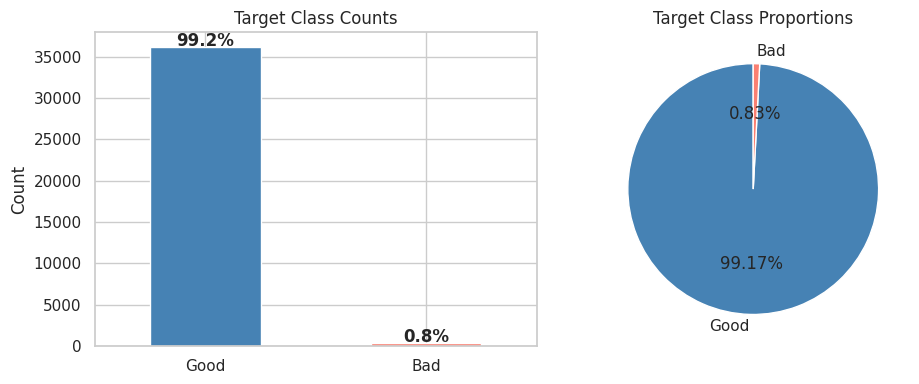

Good:Bad ratio = 120:1


In [62]:
target_counts = labelled_df["target"].value_counts()
target_labels = {0: "Good", 1: "Bad"}

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart
target_counts.rename(index=target_labels).plot.bar(ax=axes[0], color=["steelblue", "salmon"])
axes[0].set_title("Target Class Counts")
axes[0].set_ylabel("Count")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=0)

# Percentage annotations
for i, (val, count) in enumerate(target_counts.items()):
    axes[0].text(i, count + 200, f"{count / len(labelled_df):.1%}", ha="center", fontweight="bold")

# Pie chart
target_counts.rename(index=target_labels).plot.pie(
    ax=axes[1], autopct="%1.2f%%", colors=["steelblue", "salmon"], startangle=90
)
axes[1].set_ylabel("")
axes[1].set_title("Target Class Proportions")

plt.tight_layout()
plt.show()

ratio = target_counts[0] / target_counts[1]
print(f"Good:Bad ratio = {ratio:.0f}:1")

## Distribution of Numerical Features

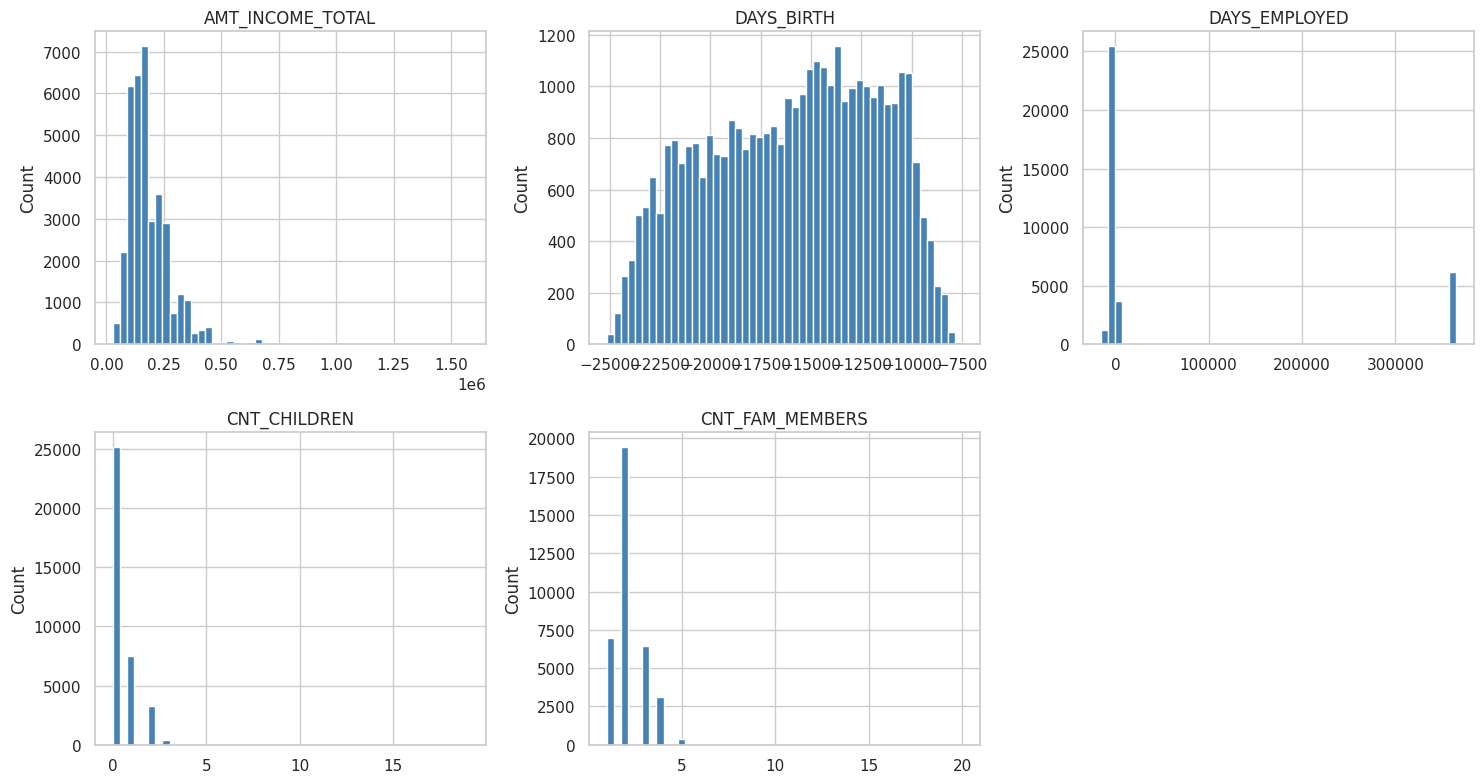

In [63]:
# Histograms for key numerical columns
num_cols = ["AMT_INCOME_TOTAL", "DAYS_BIRTH", "DAYS_EMPLOYED", "CNT_CHILDREN", "CNT_FAM_MEMBERS"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    labelled_df[col].hist(bins=50, ax=axes[i], color="steelblue", edgecolor="white")
    axes[i].set_title(col)
    axes[i].set_ylabel("Count")

axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

## Distribution of Categorical Features

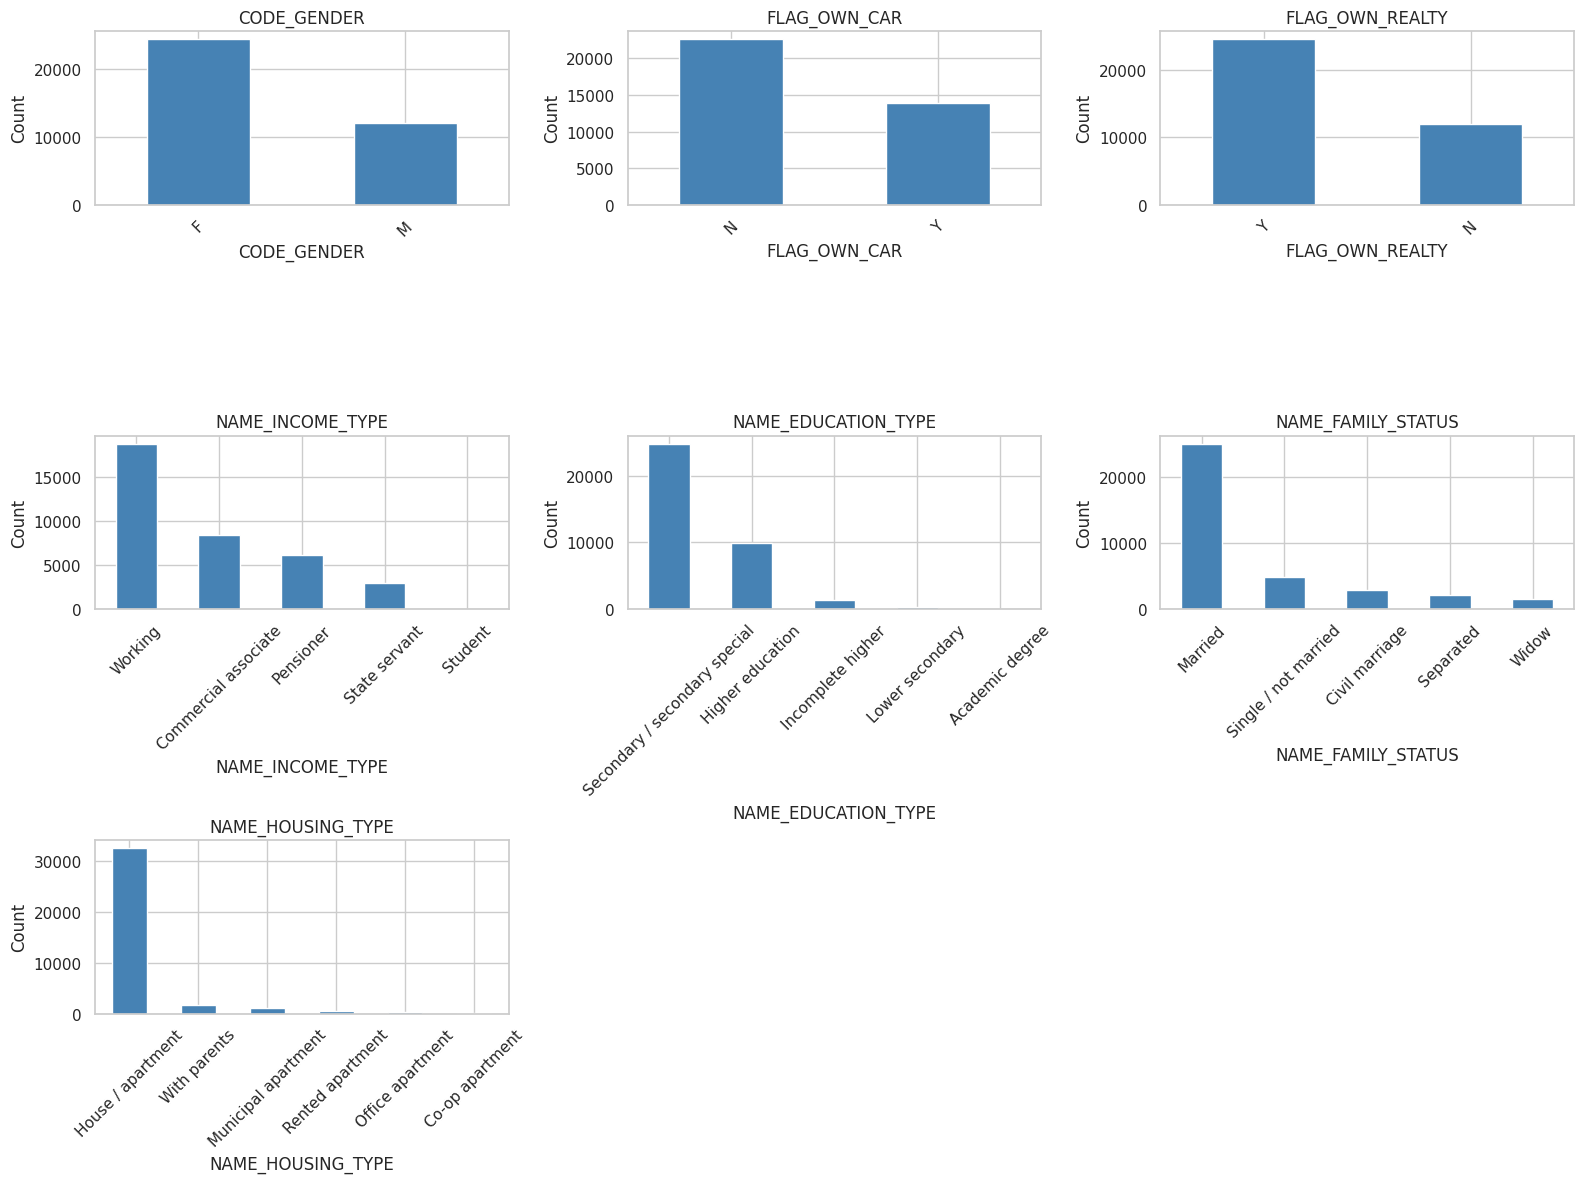

In [64]:
cat_cols = ["CODE_GENDER", "FLAG_OWN_CAR", "FLAG_OWN_REALTY",
            "NAME_INCOME_TYPE", "NAME_EDUCATION_TYPE",
            "NAME_FAMILY_STATUS", "NAME_HOUSING_TYPE"]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = labelled_df[col].value_counts()
    counts.plot.bar(ax=axes[i], color="steelblue", edgecolor="white")
    axes[i].set_title(col)
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis="x", rotation=45)

# Hide unused subplots
for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## Correlation Matrix (Numerical Features)

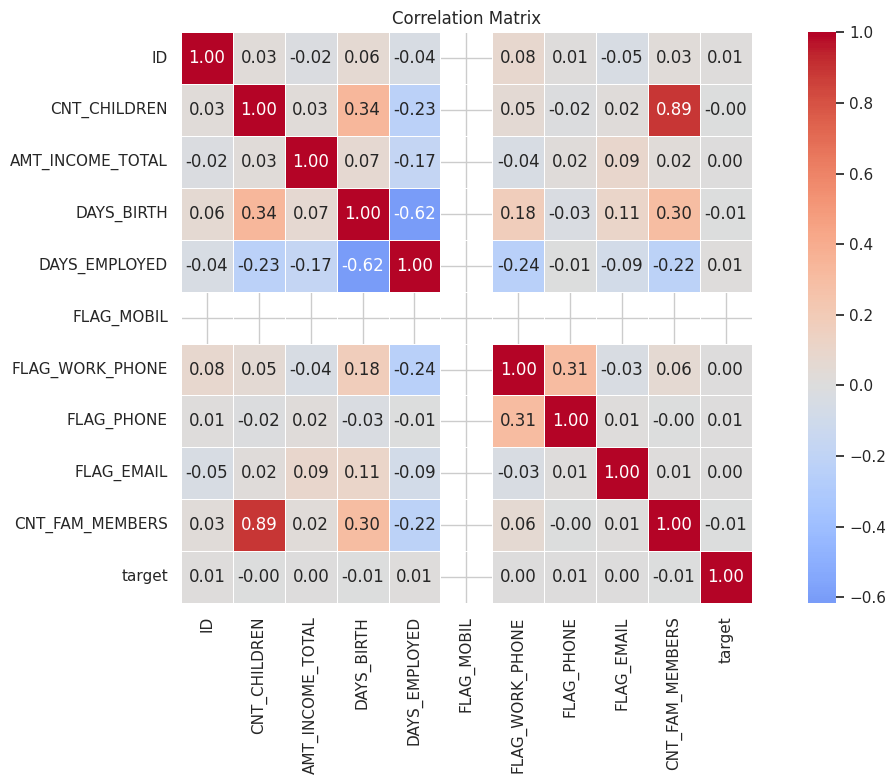

In [65]:
numeric_df = labelled_df.select_dtypes(include="number")
corr = numeric_df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, linewidths=0.5)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

# Data Processing

Clean and prepare the dataset based on EDA findings:
1. Handle duplicate IDs
2. Drop low-variance / uninformative columns
3. Handle missing values
4. Remove outliers in income
5. Convert days columns to more readable units

## Handle Duplicate IDs

Some applicants appear multiple times (same person, different applications).
Keep only the first occurrence per ID.

In [66]:
print(f"Rows before dedup: {len(labelled_df)}")
print(f"Unique IDs: {labelled_df['ID'].nunique()}")
print(f"Duplicate IDs: {labelled_df.duplicated(subset='ID').sum()}")

processed_df = labelled_df.drop_duplicates(subset="ID").reset_index(drop=True)
print(f"\nRows after dedup: {len(processed_df)}")

Rows before dedup: 36457
Unique IDs: 36457
Duplicate IDs: 0

Rows after dedup: 36457


## Drop Low-Variance / Uninformative Columns

- `FLAG_MOBIL` — nearly all 1 (everyone has a mobile phone)
- `ID` — identifier, not a feature

In [67]:
# FLAG_MOBIL is constant (all 1) — provides no predictive signal
print("FLAG_MOBIL unique values:", processed_df["FLAG_MOBIL"].unique())

drop_cols = ["ID", "FLAG_MOBIL"]
processed_df = processed_df.drop(columns=drop_cols)
print(f"\nDropped columns: {drop_cols}")
print(f"Remaining columns: {list(processed_df.columns)}")

FLAG_MOBIL unique values: [1]

Dropped columns: ['ID', 'FLAG_MOBIL']
Remaining columns: ['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'target']


## Handle Missing Values

`OCCUPATION_TYPE` has significant missing values. Fill with `"Unknown"` rather
than dropping rows, to preserve data.

In [68]:
print("Missing values before:")
print(processed_df.isnull().sum()[processed_df.isnull().sum() > 0])

processed_df["OCCUPATION_TYPE"] = processed_df["OCCUPATION_TYPE"].fillna("Unknown")

print("\nMissing values after:")
print(processed_df.isnull().sum().sum(), "total missing values")

Missing values before:
OCCUPATION_TYPE    11323
dtype: int64

Missing values after:
0 total missing values


## Convert Days Columns to Positive Years

`DAYS_BIRTH` and `DAYS_EMPLOYED` are stored as negative day counts from the
application date. Convert to positive years for interpretability.

Note: `DAYS_EMPLOYED` = 365243 is a sentinel for unemployed/pensioners.

In [69]:
# Convert negative days to positive years
processed_df["AGE_YEARS"] = (-processed_df["DAYS_BIRTH"] / 365.25).round(1)

print(processed_df["DAYS_EMPLOYED"].value_counts().sort_index())
# There are 6135 applicants with DAYS_EMPLOYED = 365243

# DAYS_EMPLOYED: 365243 (positive) is a sentinel value for unemployed/pensioners
# Replace sentinel with 0 (not currently employed), then convert
processed_df["YEARS_EMPLOYED"] = processed_df["DAYS_EMPLOYED"].replace(365243, 0)
processed_df["YEARS_EMPLOYED"] = (-processed_df["YEARS_EMPLOYED"] / 365.25).round(1)

# Ensure there are no anomalies (where YEARS_EMPLOYED exceeds age minus 18, i.e. started working before age 17)
print("\nCount of Anomalies (Started Working before Age 17):", end = " ")
print(((processed_df["YEARS_EMPLOYED"]) > (processed_df["AGE_YEARS"] - 17)).sum(), end ="\n")
print("No anomalies in the data, all applicants started working at least age 17.9", end = "\n\n")

processed_df = processed_df.drop(columns=["DAYS_BIRTH", "DAYS_EMPLOYED"])

print("AGE_YEARS stats:")
print(processed_df["AGE_YEARS"].describe())
print("\nYEARS_EMPLOYED stats:")
print(processed_df["YEARS_EMPLOYED"].describe())

DAYS_EMPLOYED
-15713        1
-15661        4
-15227        1
-15072        3
-15038       16
           ... 
-66           1
-65           2
-43           1
-17           3
 365243    6135
Name: count, Length: 3640, dtype: int64

Count of Anomalies (Started Working before Age 17): 0
No anomalies in the data, all applicants started working at least age 17.9

AGE_YEARS stats:
count    36457.000000
mean        43.738802
std         11.499888
min         20.500000
25%         34.100000
50%         42.600000
75%         53.200000
max         68.900000
Name: AGE_YEARS, dtype: float64

YEARS_EMPLOYED stats:
count    36457.000000
mean         6.023732
std          6.480074
min          0.000000
25%          1.100000
50%          4.200000
75%          8.600000
max         43.000000
Name: YEARS_EMPLOYED, dtype: float64


## Remove Income Outliers

Cap extreme income values at the 99th percentile to reduce skew.

In [70]:
print(processed_df["AMT_INCOME_TOTAL"].describe())

p99 = processed_df["AMT_INCOME_TOTAL"].quantile(0.99)

# The maximum (1,575,000) is 3x the 99% (650, 250) → >99% extreme values to be clipped
n_clipped = (processed_df["AMT_INCOME_TOTAL"] > p99).sum()

#processed_df["AMT_INCOME_TOTAL"] = processed_df["AMT_INCOME_TOTAL"].clip(upper=p99)

print(f"99th percentile income: {p99:,.0f}")
print(f"Values clipped: {n_clipped}")

count    3.645700e+04
mean     1.866857e+05
std      1.017892e+05
min      2.700000e+04
25%      1.215000e+05
50%      1.575000e+05
75%      2.250000e+05
max      1.575000e+06
Name: AMT_INCOME_TOTAL, dtype: float64
99th percentile income: 560,250
Values clipped: 363


## Drop Features that cause Multicollinearity

`CNT_CHILDREN` and `CNT_FAM_MEMBERS` have a correlation of **0.89** (the high correlation suspects that a multicollinearity might occur).
Apply Variance Inflation Factor (VIF) to confirm multicollinearity and drop plausible problematic features.

In [71]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# Select only numeric columns for VIF
numeric_df = processed_df.select_dtypes(include=["number"]).dropna()

# Calculate VIF BEFORE dropping
print("=== VIF BEFORE dropping CNT_CHILDREN ===")
vif_data = pd.DataFrame()
vif_data["Column"] = numeric_df.columns
vif_data["VIF"] = [variance_inflation_factor(numeric_df.values, i) for i in range(len(numeric_df.columns))]
print(vif_data.sort_values("VIF", ascending=False))

# VIF analysis shows CNT_FAM_MEMBERS has high multicollinearity (VIF=19.9 >> 10) vs CNT_CHILDREN (VIF=5.49)
# Drop CNT_FAM_MEMBERS instead as it is the more problematic column
processed_df = processed_df.drop(columns=["CNT_FAM_MEMBERS"])
print(f"Dropped CNT_FAM_MEMBERS (VIF=19.9) instead of CNT_CHILDREN (VIF=5.49)")

# Recalculate VIF after dropping to verify improvement
numeric_df = processed_df.select_dtypes(include=["number"]).dropna()
print("\n=== VIF AFTER dropping CNT_FAM_MEMBERS ===")
vif_data2 = pd.DataFrame()
vif_data2["Column"] = numeric_df.columns
vif_data2["VIF"] = [variance_inflation_factor(numeric_df.values, i) for i in range(len(numeric_df.columns))]
print(vif_data2.sort_values("VIF", ascending=False))

=== VIF BEFORE dropping CNT_CHILDREN ===
             Column        VIF
5   CNT_FAM_MEMBERS  19.906285
7         AGE_YEARS   9.663653
0      CNT_CHILDREN   5.489691
1  AMT_INCOME_TOTAL   4.023543
8    YEARS_EMPLOYED   1.898528
3        FLAG_PHONE   1.587464
2   FLAG_WORK_PHONE   1.477409
4        FLAG_EMAIL   1.111679
6            target   1.008919
Dropped CNT_FAM_MEMBERS (VIF=19.9) instead of CNT_CHILDREN (VIF=5.49)

=== VIF AFTER dropping CNT_FAM_MEMBERS ===
             Column       VIF
6         AGE_YEARS  3.978980
1  AMT_INCOME_TOTAL  3.780833
7    YEARS_EMPLOYED  1.879622
3        FLAG_PHONE  1.587242
2   FLAG_WORK_PHONE  1.427852
0      CNT_CHILDREN  1.290864
4        FLAG_EMAIL  1.103675
5            target  1.008898


## Final Processed Dataset

In [72]:
print(f"Final dataset shape: {processed_df.shape}")
print(f"Columns: {list(processed_df.columns)}")
print(f"\nTarget distribution:")
print(processed_df["target"].value_counts().rename({0: "Good", 1: "Bad"}))
display(processed_df.head())

Final dataset shape: (36457, 16)
Columns: ['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'target', 'AGE_YEARS', 'YEARS_EMPLOYED']

Target distribution:
target
Good    36155
Bad       302
Name: count, dtype: int64


,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,target,AGE_YEARS,YEARS_EMPLOYED
0,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,1,0,0,Unknown,0,32.9,12.4
1,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,1,0,0,Unknown,0,32.9,12.4
2,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,0,0,0,Security staff,0,58.8,3.1
3,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,0,1,1,Sales staff,0,52.3,8.4
4,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,0,1,1,Sales staff,0,52.3,8.4


In [73]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE, SMOTENC
from imblearn.pipeline import Pipeline as ImbPipeline
import numpy as np

### One-Hot Encode Categorical Features and Scale Numerical Features

Build a `ColumnTransformer` that:
- One-hot encodes all categorical columns (drops first to avoid multicollinearity)
- Standardises numerical columns

In [74]:
# Separate features and target
X = processed_df.drop(columns=["target"])
y = processed_df["target"]

# Identify column types
cat_cols = X.select_dtypes(include=["object", "string"]).columns.tolist()
num_cols = X.select_dtypes(include="number").columns.tolist()

print(f"Categorical columns ({len(cat_cols)}): {cat_cols}")
print(f"Numerical columns ({len(num_cols)}): {num_cols}")

Categorical columns (8): ['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE']
Numerical columns (7): ['CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'AGE_YEARS', 'YEARS_EMPLOYED']


In [75]:
# Preprocessor 1 — for SMOTE (encode first, then SMOTE)
preprocessor_smote = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="infrequent_if_exist", sparse_output=False), cat_cols),
    ]
)

# Preprocessor 2 — for SMOTENC (only scale numerics, NO encoding)
# SMOTENC needs raw categoricals so encoding happens AFTER
preprocessor_smotenc = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
    ],
    remainder="passthrough"  # ← keeps categorical columns as is
)

### Train/Test Split and SMOTE

Split first, then apply SMOTE **only on the training set** to avoid data leakage.

In [76]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train set: {X_train.shape[0]} samples  (bad rate: {y_train.mean():.2%})")
print(f"Test set:  {X_test.shape[0]} samples  (bad rate: {y_test.mean():.2%})")

Train set: 29165 samples  (bad rate: 0.83%)
Test set:  7292 samples  (bad rate: 0.82%)


# Model Training & Evaluation Helpers

Reusable functions for training any sklearn-compatible classifier with:
- Configurable cross-validation folds
- `GridSearchCV` for hyperparameter tuning, standardized to optimize for **PR-AUC (`average_precision`)**
- Robust `ColumnTransformer` preprocessors integrated directly into the pipeline
- SMOTE applied strictly inside the CV loop (via `imb-learn` pipeline) to prevent data leakage
- Comprehensive evaluation outputs including Classification Reports, Confusion Matrices, and Precision-Recall Curves

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, SMOTENC
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    average_precision_score,
    precision_recall_curve,
    f1_score,
    make_scorer
)

def build_pipeline(model, preprocessor=None, use_smote=True, smote_random_state=42, use_smotenc=False, categorical_indices=None):
    steps = []

    if use_smotenc and categorical_indices is not None:
        steps.append(("preprocessor", preprocessor))
        steps.append(("smote", SMOTENC(
            categorical_features=categorical_indices,
            random_state=smote_random_state
        )))
        steps.append(("encoder", ColumnTransformer(
            transformers=[
                ("cat", OneHotEncoder(
                    drop="first",
                    handle_unknown="infrequent_if_exist",
                    sparse_output=False
                ), categorical_indices)
            ],
            remainder="passthrough"
        )))
    else:
        if preprocessor is not None:
            steps.append(("preprocessor", preprocessor))
        if use_smote:
            steps.append(("smote", SMOTE(random_state=smote_random_state)))

    steps.append(("model", model))
    return ImbPipeline(steps)


def train_with_gridsearch(
    model, param_grid, X_train, y_train, preprocessor=None, cv_folds=5,
    scoring="average_precision",
    use_smote=True, random_state=42, n_jobs=-1, use_smotenc=False, categorical_indices=None
):
    pipeline = build_pipeline(model, preprocessor=preprocessor, use_smote=use_smote, use_smotenc=use_smotenc, categorical_indices=categorical_indices)
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=random_state)
    grid_search = GridSearchCV(
        estimator=pipeline, param_grid=param_grid, cv=cv, scoring=scoring,
        n_jobs=n_jobs, refit=True, return_train_score=True, verbose=1,
    )
    grid_search.fit(X_train, y_train)
    print(f"Best {scoring} score (CV): {grid_search.best_score_:.4f}")
    print(f"Best params: {grid_search.best_params_}")
    return grid_search


def evaluate_model(grid_search, X_test, y_test):
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)

    y_proba = None
    if hasattr(best_model, "predict_proba"):
        y_proba = best_model.predict_proba(X_test)[:, 1]
    elif hasattr(best_model, "decision_function"):
        y_proba = best_model.decision_function(X_test)

    print("=== Classification Report ===")
    print(classification_report(y_test, y_pred, target_names=["Good", "Bad"]))

    f1 = f1_score(y_test, y_pred)
    results = {"y_pred": y_pred, "y_proba": y_proba, "f1": f1}

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, display_labels=["Good", "Bad"], cmap="Blues", ax=axes[0]
    )
    axes[0].set_title("Confusion Matrix")

    if y_proba is not None:
        precision, recall, _ = precision_recall_curve(y_test, y_proba)
        pr_auc = average_precision_score(y_test, y_proba)
        baseline = y_test.mean()

        axes[1].plot(recall, precision, label=f"PR AUC = {pr_auc:.4f}", color="steelblue", linewidth=2)
        axes[1].axhline(y=baseline, color="k", linestyle="--", alpha=0.4, label=f"Baseline = {baseline:.4f}")
        axes[1].set_xlabel("Recall")
        axes[1].set_ylabel("Precision")
        axes[1].set_title("Precision-Recall Curve")
        axes[1].legend()

        results["pr_auc"] = pr_auc
        print(f"PR AUC: {pr_auc:.4f}")
    else:
        axes[1].text(0.5, 0.5, "No probability output", ha="center", va="center")
        axes[1].set_title("PR Curve (unavailable)")
        results["pr_auc"] = None

    plt.tight_layout()
    plt.show()
    return results

### Logistic Regression with L1 Regularization (Lasso)

In this section, we train a Logistic Regression model using L1 regularization for feature selection. To ensure SMOTE can properly process our string and categorical variables, we pass a dedicated `ColumnTransformer` preprocessor into our training pipeline. The hyperparameters are tuned via Grid Search, optimizing for **PR-AUC** to tackle the severe class imbalance.

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best average_precision score (CV): 0.0158
Best params: {'model__C': 0.01}

=== Logistic Regression (L1) Results ===
=== Classification Report ===
              precision    recall  f1-score   support

        Good       1.00      0.59      0.74      7232
         Bad       0.01      0.72      0.03        60

    accuracy                           0.59      7292
   macro avg       0.51      0.65      0.39      7292
weighted avg       0.99      0.59      0.74      7292

PR AUC: 0.0174


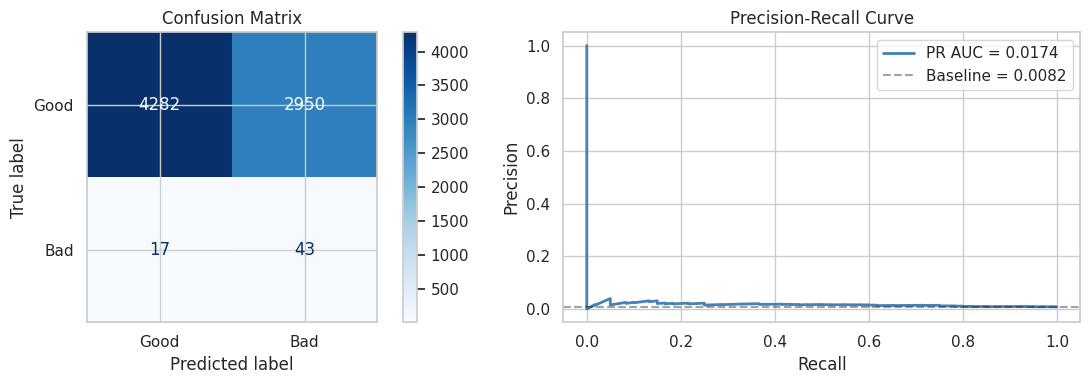

In [78]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression


lr_cat_cols = X.select_dtypes(include=["object", "string"]).columns.tolist()
binary_cols = ['FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL']
lr_cat_cols.extend([col for col in binary_cols if col in X.columns])

lr_num_cols = [col for col in X.columns if col not in lr_cat_cols]


lr_preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), lr_num_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), lr_cat_cols)
    ]
)


lr_l1_model = LogisticRegression(penalty='l1', solver='liblinear', random_state=42)

lr_l1_param_grid = {
    'model__C': [0.01, 0.1, 1, 10]
}


lr_l1_grid = train_with_gridsearch(
    model=lr_l1_model,
    param_grid=lr_l1_param_grid,
    X_train=X_train,
    y_train=y_train,
    cv_folds=5,
    scoring="average_precision",
    use_smote=True,
    preprocessor=lr_preprocessor
)

print("\n=== Logistic Regression (L1) Results ===")
lr_results = evaluate_model(lr_l1_grid, X_test, y_test)

In [79]:
from sklearn.preprocessing import LabelEncoder

X_train_enc = X_train.copy()
X_test_enc = X_test.copy()

le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    X_train_enc[col] = le.fit_transform(X_train[col])
    X_test_enc[col] = le.transform(X_test[col])
    le_dict[col] = le

categorical_indices = [X_train_enc.columns.get_loc(col) for col in cat_cols]
print("Done!")

Done!


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best average_precision score (CV): 0.0181
Best params: {'model__C': 0.01, 'model__l1_ratio': 0.5}

=== Elastic Net with Interaction Terms ===
=== Classification Report ===
              precision    recall  f1-score   support

        Good       0.99      0.59      0.74      7232
         Bad       0.01      0.63      0.02        60

    accuracy                           0.59      7292
   macro avg       0.50      0.61      0.38      7292
weighted avg       0.99      0.59      0.74      7292

PR AUC: 0.0181


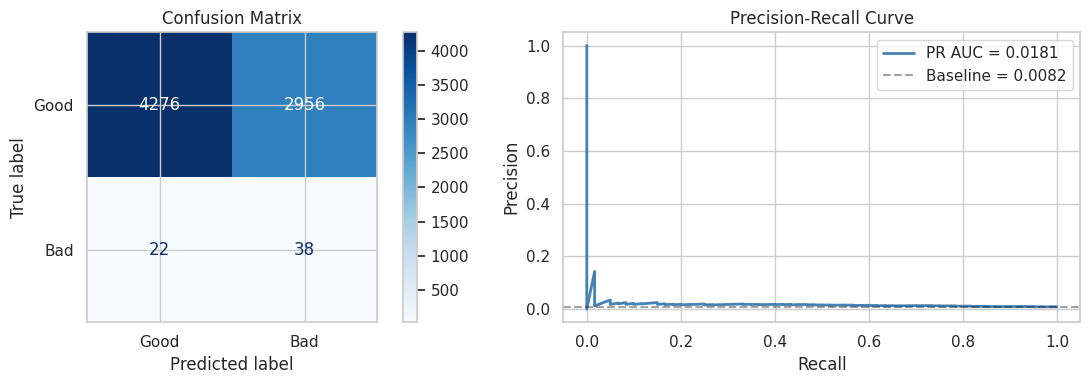

In [84]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

interact_cat_cols = X_train_interact.select_dtypes(include=["object", "string"]).columns.tolist()
binary_cols = ['FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL']
interact_cat_cols.extend([col for col in binary_cols if col in X_train_interact.columns])

interact_num_cols = [col for col in X_train_interact.columns if col not in interact_cat_cols]

lr_interact_preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), interact_num_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), interact_cat_cols)
    ]
)

lr_elastic_model_interaction = LogisticRegression(
    penalty='elasticnet', max_iter=5000, solver="saga", random_state=42
)

lr_elastic_param_grid_interaction = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__l1_ratio": [0, 0.2, 0.5, 0.8, 1]
}

lr_interact_grid = train_with_gridsearch(
    model=lr_elastic_model_interaction,
    param_grid=lr_elastic_param_grid_interaction,
    X_train=X_train_interact,
    y_train=y_train,
    cv_folds=5,
    scoring="average_precision",
    use_smote=True,
    n_jobs=-1,
    preprocessor=lr_interact_preprocessor
)

print("\n=== Elastic Net with Interaction Terms ===")
lr_interact_results = evaluate_model(lr_interact_grid, X_test_interact, y_test)

### Support Vector Machine

Fitting 2 folds for each of 6 candidates, totalling 12 fits
Best average_precision score (CV): 0.0600
Best params: {'model__C': 1, 'model__gamma': 'scale'}

=== SVM Results ===
=== Classification Report ===
              precision    recall  f1-score   support

        Good       0.99      0.94      0.97      7232
         Bad       0.05      0.40      0.10        60

    accuracy                           0.94      7292
   macro avg       0.52      0.67      0.53      7292
weighted avg       0.99      0.94      0.96      7292

PR AUC: 0.0547


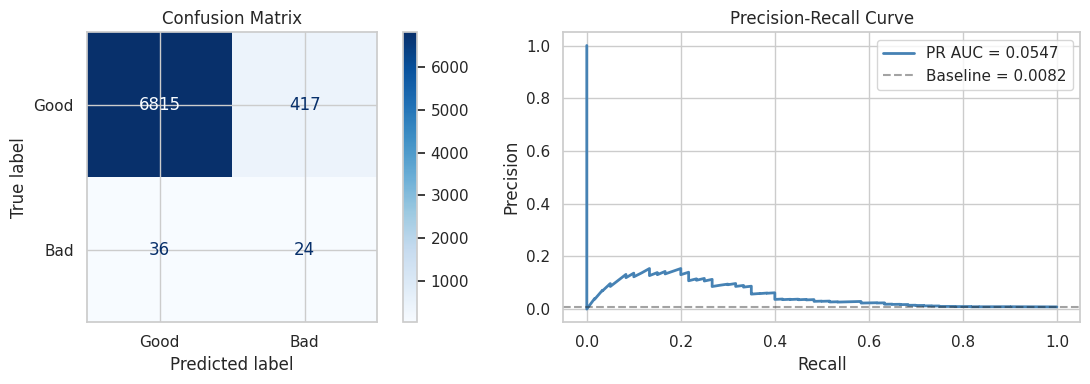

In [83]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel="rbf",
    random_state=42,
    class_weight="balanced",
    probability=True
)

svm_param_grid = {
    "model__C": [0.01, 0.1, 1],
    "model__gamma": ["scale", "auto"],
}

svm_grid = train_with_gridsearch(
    model=svm_model,
    param_grid=svm_param_grid,
    X_train=X_train,
    y_train=y_train,
    cv_folds=2,
    scoring="average_precision",
    use_smote=True,
    n_jobs=1,
    preprocessor=lr_preprocessor
)

print("\n=== SVM Results ===")
svm_results = evaluate_model(svm_grid, X_test, y_test)

### K-Nearest Neighbors (KNN) Model Pipeline

As KNN relies on distance metrics, it is highly sensitive to feature scales and high-dimensional sparse data. In this section, we build a KNN model with the following robust pipeline:
1. Standardizing numerical features and One-Hot encoding categorical/binary features via a tailored `ColumnTransformer`.
2. Handling the severe class imbalance strictly within the cross-validation loops to prevent data leakage.
3. Using `GridSearchCV` optimized for the **`average_precision` (PR-AUC)** score to find the best $K$ value and weight strategy, which effectively identifies the minority "Bad" customers.

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best average_precision score (CV): 0.0693
Best params: {'model__n_neighbors': 11, 'model__weights': 'distance'}
KNN Results
=== Classification Report ===
              precision    recall  f1-score   support

        Good       0.99      0.99      0.99      7232
         Bad       0.12      0.22      0.15        60

    accuracy                           0.98      7292
   macro avg       0.55      0.60      0.57      7292
weighted avg       0.99      0.98      0.98      7292

PR AUC: 0.0701


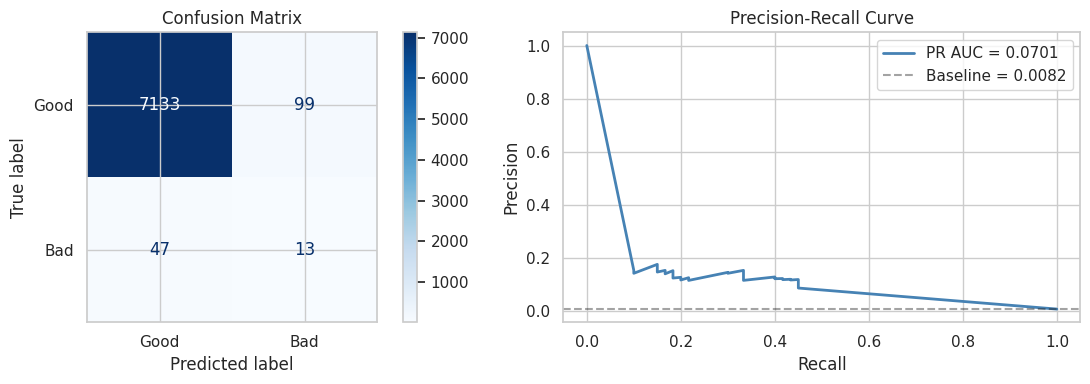

In [85]:
from sklearn import neighbors
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    average_precision_score,
    precision_recall_curve,
    f1_score,
    make_scorer
)
import matplotlib.pyplot as plt

knn_cat_cols = X.select_dtypes(include=["object", "string"]).columns.tolist()
binary_cols = ['FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL']
knn_cat_cols.extend([col for col in binary_cols if col in X.columns])

knn_num_cols = [col for col in X.columns if col not in knn_cat_cols]

knn_preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), knn_num_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), knn_cat_cols)
    ]
)

knn_model = neighbors.KNeighborsClassifier(n_jobs=-1)

param_grid_knn = {
    'model__n_neighbors': [3, 5, 7, 9, 11],
    'model__weights': ['uniform', 'distance']
}

grid_knn = train_with_gridsearch(
    model=knn_model,
    param_grid=param_grid_knn,
    X_train=X_train,
    y_train=y_train,
    cv_folds=3,
    scoring="average_precision",
    use_smote=True,
    preprocessor=knn_preprocessor
)

print("KNN Results")
knn_results = evaluate_model(grid_knn, X_test, y_test)